In [1]:
using CSV
using DataFrames
using CairoMakie
using LsqFit

In [2]:
#Daten aus Datei nehmen
df = CSV.read("Messdaten_Pulverdiffraktonomie/Probe2_Messdaten.xye", DataFrame, delim=' ', ignorerepeated=true, 
skipto=2, header=["zwei_theta", "I", "ΔI"])

zwei_θ = df.zwei_theta
I = df.I
ΔI = df.ΔI;

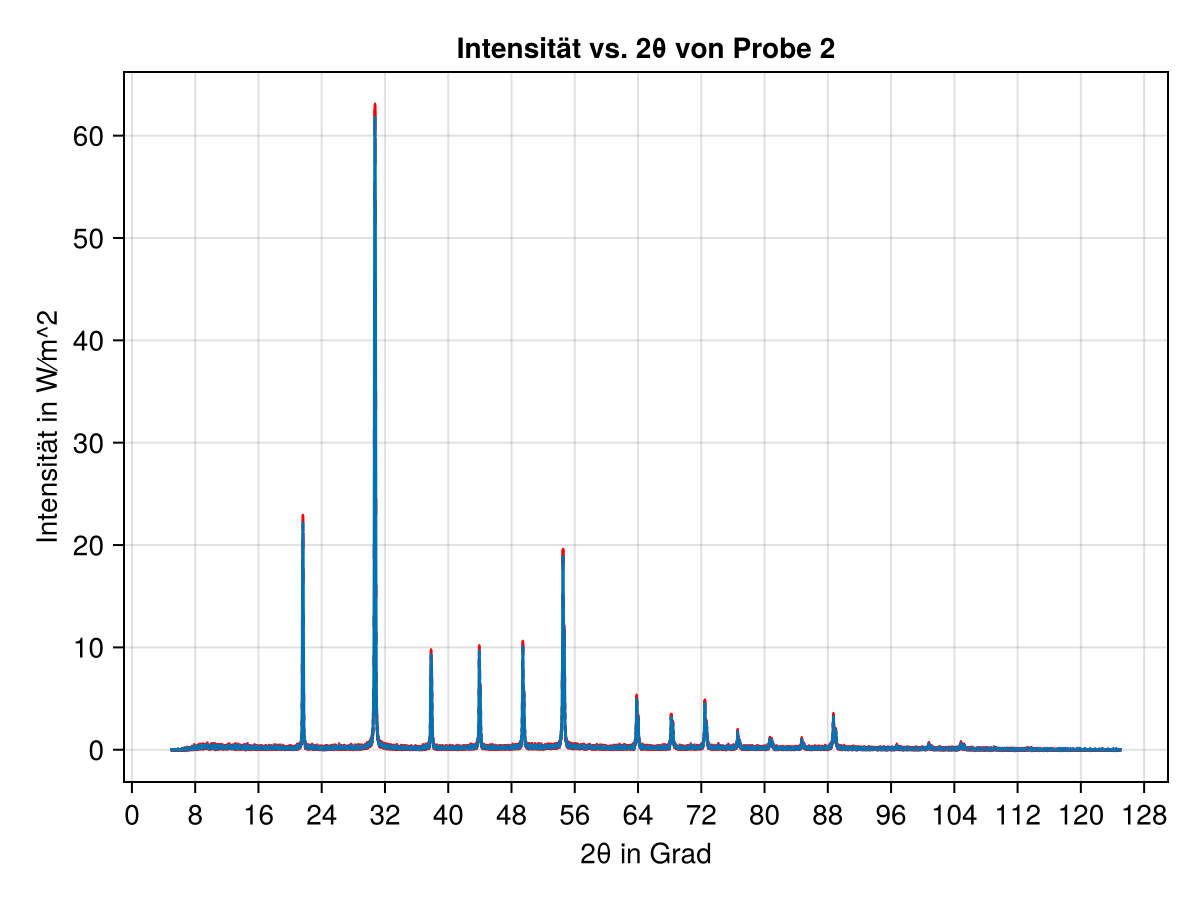

In [3]:
#Intensität vs 2theta
fig, ax, eb = errorbars(zwei_θ, I, ΔI, color = :red, whiskerwidth = 1)
scatterlines!(ax, zwei_θ, I, markersize = 2)

ax.xticks = LinearTicks(20)
ax.yticks = LinearTicks(8)
ax.title = "Intensität vs. 2θ von Probe 2"
ax.xlabel = "2θ in Grad"
ax.ylabel = "Intensität in W⁄m^2"
fig

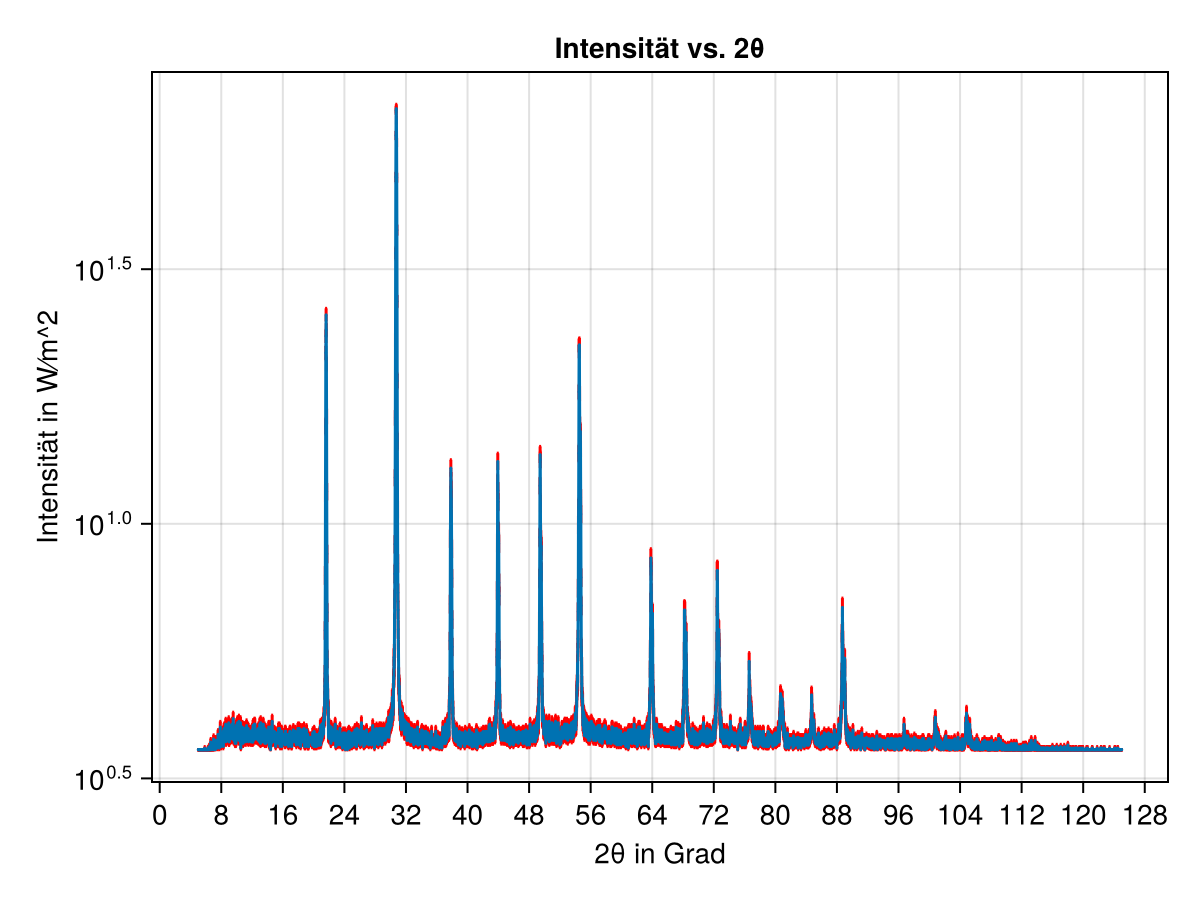

In [18]:
#Intensität mit log-skala
fig, ax, eb = errorbars(zwei_θ, I.+3.6, ΔI, color = :red, whiskerwidth = 1)
scatterlines!(ax, zwei_θ, I.+3.6, markersize = 2)

ax.xticks = LinearTicks(20)
ax.yscale = log10
#ax.xscale = log10
ax.title = "Intensität vs. 2θ"
ax.xlabel = "2θ in Grad"
ax.ylabel = "Intensität in W⁄m^2"
fig

Fit fehlgeschlagen bei Zentrum 26.8
Fit fehlgeschlagen bei Zentrum 122.0


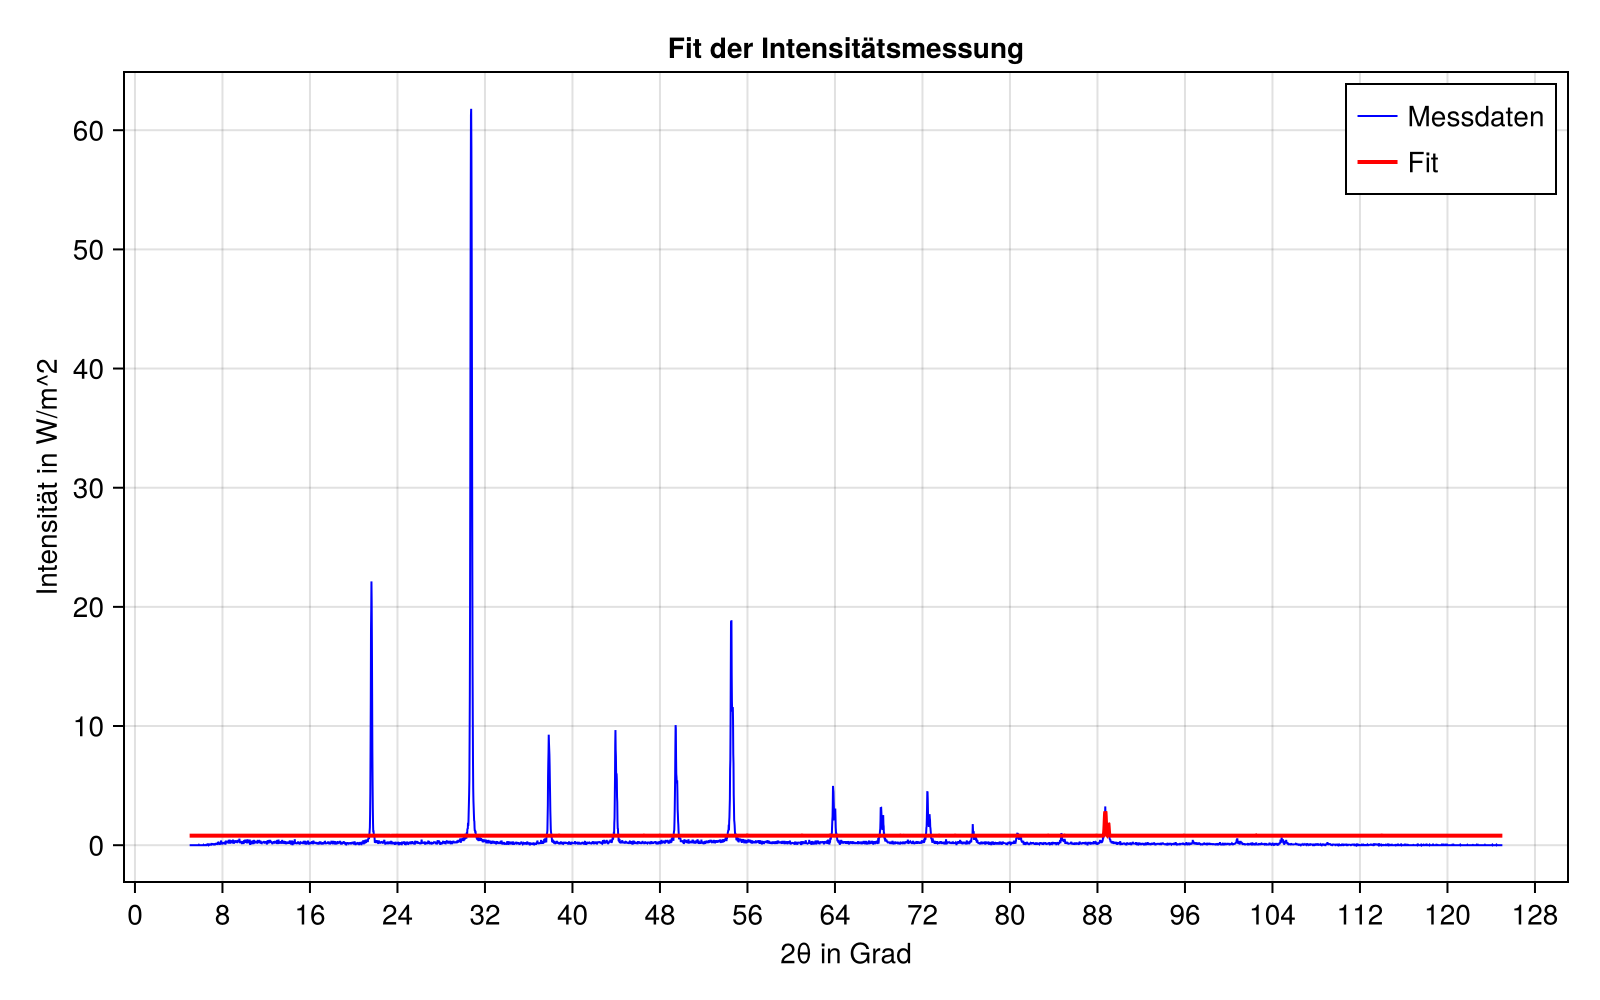

CairoMakie.Screen{IMAGE}


In [16]:
#Behalten

function doppel_gauß_einzeln(x, p)
    g1 = p[1] .* exp.(-(x .- p[2]).^2 ./ (2 .* p[3]^2))
    g2 = (p[1] / 2) .* exp.(-(x .- p[4]).^2 ./ (2 .* p[5]^2))
    return g1 .+ g2
end

peak_zentren = [23.9, 26.8, 38.8, 46.5, 48.0, 56.0, 61.0, 63.5, 70, 73.5, 75.0, 83.5, 85.0, 87.9, 88.9, 95.9, 102.5, 114.0, 122.0] 

fit_ergebnisse = []
untergrund_fest = 0.8 

# Jeden Peak einzeln fitten in einer Schleife
for zentrum in peak_zentren
    # Fensterbreiten für optimalen Spitzen-Fit
    if zentrum == 26.8
        f_breite = 1.0
    elseif zentrum == 63.8 || zentrum == 71.0
        f_breite = 0.4
    else
        f_breite = 0.8
    end
    
    bereich = (zwei_θ .> zentrum - f_breite) .& (zwei_θ .< zentrum + f_breite)
    
    x_sub = zwei_θ[bereich]
    y_sub = I[bereich]
    
    if isempty(x_sub) continue end
    
    # Standard-Startwerte
    amp_start = max(0.1, maximum(y_sub) - untergrund_fest)
    p0 = [amp_start, zentrum, 0.05, zentrum + 0.04, 0.05] 
    
    # Spezialbehandlung für den Riesenpeak bei 26.8°
    if zentrum == 26.8
        x_max_lokal = x_sub[argmax(y_sub)]
        p0 = [maximum(y_sub) - untergrund_fest, x_max_lokal, 0.08, x_max_lokal + 0.04, 0.08]
    end
    
    model_lokal(x, p) = doppel_gauß_einzeln(x, p) .+ untergrund_fest
    
    # Physikalische Grenzen
    if zentrum == 26.8
        untere_grenzen = [10.0,  25.5,  0.01,  25.5,  0.01]
        obere_grenzen  = [700.0,  28.0,  0.3,   28.0,  0.3]
    else
        untere_grenzen = [0.1,             zentrum - 0.5,  0.005,  zentrum - 0.5,  0.005]
        obere_grenzen  = [maximum(y_sub)*2, zentrum + 0.5,  0.3,    zentrum + 0.5,  0.3]
    end
    
    try
        fit = curve_fit(model_lokal, x_sub, y_sub, p0, lower=untere_grenzen, upper=obere_grenzen)
        p_opt = coef(fit)
        
        # KORREKTUR: Wir prüfen nur noch, ob die Amplitude positiv ist. 
        # Die Breite wird vollautomatisch über 'obere_grenzen' auf maximal 0.3 limitiert!
        if p_opt[1] > 0.0
            push!(fit_ergebnisse, (params=p_opt, bereich=bereich, zentrum_soll=zentrum))
        end
    catch e
        println("Fit fehlgeschlagen bei Zentrum $zentrum")
    end
end

# 4. Gesamtkurve zusammensetzen
y_gesamt = fill(untergrund_fest, length(zwei_θ))

for fit in fit_ergebnisse
    y_peak = doppel_gauß_einzeln(zwei_θ, fit.params)
    global y_gesamt += y_peak
end

# 5. Plotten
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], 
    title = "Fit der Intensitätsmessung",
    xlabel = "2θ in Grad",
    ylabel = "Intensität in W/m^2"
)

lines!(ax, zwei_θ, I, color = :blue, linewidth = 1, label = "Messdaten")
lines!(ax, zwei_θ, y_gesamt, color = :red, linewidth = 2, label = "Fit")

ax.xticks = LinearTicks(20)
ax.yticks = LinearTicks(8)

axislegend(ax)
display(fig)




In [43]:
println("\n==========================================================")
println("  EXAKTE POSITIONEN DER GEFITTETEN PEAKS (2θ in Grad)")
println("==========================================================")

for (i, fit) in enumerate(fit_ergebnisse)
    # Runden auf 4 Nachkommastellen für die physikalische Präzision
    pos_ka1 = round(fit.params[2], digits=4)
    pos_ka2 = round(fit.params[4], digits=4)
    
    println("Peak #$i:   Kα1 = $(pos_ka1)°   |   Kα2 = $(pos_ka2)°")
end


  EXAKTE POSITIONEN DER GEFITTETEN PEAKS (2θ in Grad)
Peak #1:   Kα1 = 23.7058°   |   Kα2 = 23.6936°
Peak #2:   Kα1 = 27.384°   |   Kα2 = 27.3866°
Peak #3:   Kα1 = 38.9082°   |   Kα2 = 39.0191°
Peak #4:   Kα1 = 46.0°   |   Kα2 = 47.0°
Peak #5:   Kα1 = 48.0456°   |   Kα2 = 48.1826°
Peak #6:   Kα1 = 55.9955°   |   Kα2 = 56.0829°
Peak #7:   Kα1 = 60.5018°   |   Kα2 = 61.5°
Peak #8:   Kα1 = 63.2864°   |   Kα2 = 63.6035°
Peak #9:   Kα1 = 70.0477°   |   Kα2 = 70.1642°
Peak #10:   Kα1 = 73.4696°   |   Kα2 = 73.4257°
Peak #11:   Kα1 = 74.9636°   |   Kα2 = 75.0893°
Peak #12:   Kα1 = 83.0°   |   Kα2 = 83.2855°
Peak #13:   Kα1 = 84.9633°   |   Kα2 = 85.5°
Peak #14:   Kα1 = 87.6634°   |   Kα2 = 87.8797°
Peak #15:   Kα1 = 88.827°   |   Kα2 = 89.2163°
Peak #16:   Kα1 = 95.4714°   |   Kα2 = 95.9606°
Peak #17:   Kα1 = 102.0°   |   Kα2 = 102.0448°
Peak #18:   Kα1 = 113.5°   |   Kα2 = 114.5°
Peak #19:   Kα1 = 121.8617°   |   Kα2 = 122.2564°


In [ ]:
#Sc as there are so goddamn many? Wenn ich richtig verstanden wie Sc ist